### Extended Data Figure 6a
This notebook provides the example code to generate **Extended Data Figure 6a** for the Glioblastoma cohort, by setting `cohort = "GBM"`. 
The same notebook can be run to generate Extended Data Figure 7a for the Pancreatic Cancer cohort, by setting `cohort = "PDAC"` in the cell below.

Setup user-defined parameters. Specify the `cohort` to be analyzed to be either "GBM" (default), "PDAC" or "COAD".

In [1]:
cohort = "GBM"  # "GBM" for Extended Data Figure 6a or "PDAC" for Extended Data Figure 7a

Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub repository as `Code_dir`.

In [2]:
Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/HCMI-single-nuclei/" # path to GitHub folder

Specify Case IDs to be displayed for the cohort of interest and paths to metadata (the user doesn't need to change anything below this line) if the corresponding data and metadata have been downloaded from FigShare.

In [3]:
# Path to metadata
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata

# Case IDs (no need to edit)
if cohort == "GBM":
    cases=["HCM-BROD-0416-C71", "HCM-BROD-0415-C71", "HCM-BROD-0012-C71", "HCM-BROD-0199-C71", "HCM-BROD-0028-C71",  "HCM-BROD-0213-C71", "HCM-BROD-0002-C71"]

elif cohort == "PDAC":
    cases=["HCM-CSHL-0073-C25", "HCM-CSHL-0078-C25", "HCM-CSHL-0089-C25", "HCM-BROD-0110-C25"]

elif cohort == "COAD":
    cases=["HCM-CSHL-0143-C20", "HCM-CSHL-0322-C20", "HCM-BROD-0001-C18"]


# sample assignments from demultiplexing (no need to edit)
filtering_level_vcf = "filtered_01" # "no_filtered": VCFs; "filtered": VCFs filtered at MAF>=1%, "filtered_01": VCFs filtered at MAF >=0.1%
sample_assignment = "best_gt_thresh" # "best_gt_thresh"; "sng1st_gt" 

# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")

Import the packages needed, specify custom function to pull malignant cells from metadata and set custom plotting parameters

In [4]:
# import packages
import sys
import os
import re
import gc
import hdf5plugin
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
sys.path.append('../funcs')
from processing_funcs import *

# Specify custom function
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]
    
# Specify custom plotting parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

Load snRNA-seq metadata 

In [5]:
snRNAseq_metadata_path = f"{Code_dir}Matched Model_Tumor for Sequencing.xlsx" # "Samplesheet_for_Analysis"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load data and retrieve malignant cells for each tumor

In [6]:
adata_samples = {}  # initialize dictionary collecting AnnData object
metadata_samples_to_display = {} # initialize dictionary collecting metadata to display
for case in cases:

    print(f"Case: {case}")
    print("Retaining only cells from the Tumor (not the model)")
    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed
    case_metadata = case_metadata[case_metadata["Tumor or Model"] == "T"] # subset for the Case ID being analyzed

    #case_metadata = case_metadata[case_metadata["Tumor or Model"] == "M"] # retain only models
    # prepare sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data    

    ''' 
    ###################################################################################################
    # snRNA-seq Preprocessing

    # Load gene expression data and include it into AnnData object
    # Subset for only the cells that previously passed QC and then only for putative malignant cells
    # Subset of only putative tumor cells
    # Data preprocessing
    ###################################################################################################
    '''

    # Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        
        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Adding column for putative tumor cells")

        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata
        
        # Subset of only putative tumor cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)

        if clusters_putative_malignant != "all":
            adata_samples[sample].obs['infercnv_malignant'] = adata_samples[sample].obs['clusters'].apply(lambda cluster: 'malignant' if cluster in clusters_putative_malignant else 'normal')

            if cohort == "PDAC":
                #adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample].obs['infercnv_malignant'] = adata_samples[sample].obs.apply(
                    lambda row: 'malignant' if row['clusters'] in clusters_putative_malignant and row["singler_BpE_cg"] == "Epithelial cells" else 'normal',
                    axis=1
                )

            if cohort == "COAD":
                adata_samples[sample].obs['infercnv_malignant'] = adata_samples[sample].obs.apply(
                    lambda row: 'malignant' if row['clusters'] in clusters_putative_malignant and row["singler_BpE_cg"] in ["Epithelial cells", "Neurons"] else 'normal',
                    axis=1
                )

        else:
            adata_samples[sample].obs["infercnv_malignant"] = "malignant"
        adata_samples[sample].obs.set_index("barcode", inplace=True) # set index

        metadata_samples_to_display[sample] = adata_samples[sample].obs 

# set RAM free
del adata_samples 
gc.collect()

Case: HCM-BROD-0416-C71
Retaining only cells from the Tumor (not the model)
Loading ID AG006_HCM-BROD-0416-C71 : AnnData of dimensions (8267, 38606)
Adding column for putative tumor cells
Case: HCM-BROD-0415-C71
Retaining only cells from the Tumor (not the model)
Loading ID AA016_HCM-BROD-0415-C71 : AnnData of dimensions (10615, 38606)
Adding column for putative tumor cells
Case: HCM-BROD-0012-C71
Retaining only cells from the Tumor (not the model)
Loading ID AA014_HCM-BROD-0012-C71 : AnnData of dimensions (8563, 38606)
Adding column for putative tumor cells
Case: HCM-BROD-0199-C71
Retaining only cells from the Tumor (not the model)
Loading ID AA014_HCM-BROD-0199-C71 : AnnData of dimensions (6035, 38606)
Adding column for putative tumor cells
Case: HCM-BROD-0028-C71
Retaining only cells from the Tumor (not the model)
Loading ID AG004_HCM-BROD-0028-C71 : AnnData of dimensions (26785, 38606)
Adding column for putative tumor cells
Case: HCM-BROD-0213-C71
Retaining only cells from the Tumo

6647

Generate dataframes for downstream visualization

In [7]:
variables = ["malignant", "normal"]
# all samples
samples = list(metadata_samples_to_display.keys())

# Prepare the dataframe to plot as a radar plot
df_barplot_all = pd.DataFrame()
n_cells_all = pd.DataFrame()
for sample in samples[::-1]:
    df_barplot = pd.DataFrame(metadata_samples_to_display[sample]["infercnv_malignant"].value_counts()).T
    df_barplot = df_barplot.reindex(columns=variables, fill_value=0)
    n_cells = pd.DataFrame({"sample": [sample], "n_cells": [df_barplot.sum().sum()]})
    #df_radar = df_radar[sorted_pathways]
    df_barplot.index = [sample]
    df_barplot = df_barplot.div(df_barplot.sum(axis=1), axis=0) * 100
    df_barplot_all = pd.concat([df_barplot_all, df_barplot])
    n_cells_all = pd.concat([n_cells_all, n_cells])

df_barplot_all = df_barplot_all.drop(columns={"normal"})

df_barplot_all = df_barplot_all.merge(n_cells_all, left_index=True, right_on='sample')
df_barplot_all = df_barplot_all.set_index("sample")

Simplify Sample IDs for plotting

In [8]:
if cohort == "GBM":
    df_barplot_all.index = df_barplot_all.index.str.extract(r'(\d{3})-C71')[0].rename('')
elif cohort == "PDAC":

    def rename_index(index_value):
        prefix, identifier = index_value.split('_')[0], index_value.split('-')[2][:4]
        
        # Handle specific cases for "078" and "089"
        if identifier == "0089":
            return "0089" if prefix == "AG010" else "0089m"
        elif identifier == "0078":
            return "0078" if prefix == "AG010" else "0078m"
        else:
            return identifier  # Return just the three-digit identifier for other cases

    df_barplot_all.index = df_barplot_all.index.map(rename_index)
    df_barplot_all.index = df_barplot_all.index.str.replace(r'^0', '', regex=True)

Generate barplots for **Extended Data Figure 6a** (if cohort is GBM) or **Extended Data Figure 7a** (if cohort is PDAC)

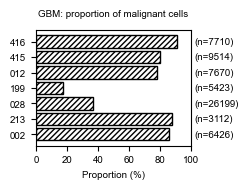

In [9]:
fig, ax = plt.subplots(figsize=(2, 1.5))  # Assign figure to a variable
#plt.barh(df_barplot_all.index, df_barplot_all['malignant'], color='black')  # Bar color
plt.barh(df_barplot_all.index, df_barplot_all['malignant'], color='white', edgecolor='black', hatch='//////')  # Bar color and hatch pattern
plt.xlim(0, 100)
plt.grid(False)
plt.xlabel('Proportion (%)', fontsize=7)
#plt.ylabel('Sample', fontsize=20)
plt.title(f"{cohort}: proportion of malignant cells", fontsize=7, y=1.05)
for i, row in df_barplot_all.iterrows():
    # Position the text on the right side of the y-axis (adjust the 105% based on your preference)
    plt.text(102, i, f"(n={round(row['n_cells'])})", ha='left', va='center', fontsize=7)
plt.tick_params(axis='x', which='both', labelleft=True, labelright=False, labelsize=7)
plt.tick_params(axis='y', which='both', labelleft=True, labelright=False, labelsize=7)
plt.show()